In [1]:
# Imports for the basic train/test
from torchvision import datasets
import torchvision
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# This is all class code.

# Train / Test Arrays to append into for MNIST
XTrain = []
yTrain = []
XTest = []
yTest = []

# Normalize Transform
normalize_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# Train the model off MNIST
trainDataset = datasets.MNIST("./MNIST", train=True,
transform=normalize_transform, download=True)
testDataset = datasets.MNIST("./MNIST", train=False,
transform=normalize_transform, download=True)

# Train Dataset
for img, label in trainDataset:
    XTrain.append(img.numpy().flatten())
    yTrain.append(label)

# Test Dataset
for img, label in testDataset:
    XTest.append(img.numpy().flatten())
    yTest.append(label)


BEGIN...load data and transform

In [2]:
# Scaled (testing to see if it runs better w/ this or if I just need the normalize in the start) (It doesn't.)
#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(XTrain)
#X_test_scaled = scaler.transform(XTest)


In [3]:
# Actual SVM model,  from GeeksForGeeks.
from joblib import dump
from sklearn.svm import SVC
"""
Sources:
https://stackoverflow.com/questions/56107259/how-to-save-a-trained-model-by-scikit-learn
https://www.geeksforgeeks.org/machine-learning/classifying-data-using-support-vector-machinessvms-in-python/
https://scikit-learn.org/stable/modules/svm.html
https://scikit-learn.org/stable/model_persistence.html
"""
svm_classifier = SVC(kernel='rbf', C=1.0, random_state=42)
svm_classifier.fit(XTrain, yTrain)

# Save the model with joblib.
dump(svm_classifier, "./MODELS/svm_mnist.joblib")

['./MODELS/svm_mnist.joblib']

In [4]:
# Accuracy test with table on MNIST.
yPred = svm_classifier.predict(XTest)
print(f"Accuracy: {accuracy_score(yTest, yPred):.2f}")
print(classification_report(yTest, yPred))

Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.97      0.97      1028
           8       0.97      0.98      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [5]:
# This whole thing is just to see if I'm processing my data correctly.
import os

imageDirectory = "./IMAGES"
one_count = 0
two_count = 0
three_count = 0
four_count = 0
five_count = 0
six_count = 0
seven_count = 0
eight_count = 0
nine_count = 0
zero_count = 0

for i in os.listdir(imageDirectory):
    if i.startswith("1"):
        one_count += 1
    if i.startswith("2"):
        two_count += 1
    if i.startswith("3"):
        three_count += 1
    if i.startswith("4"):
        four_count += 1
    if i.startswith("5"):
        five_count += 1
    if i.startswith("6"):
        six_count += 1
    if i.startswith("7"):
        seven_count += 1
    if i.startswith("8"):
        eight_count += 1
    if i.startswith("9"):
        nine_count += 1
    if i.startswith("0"):
        zero_count +=1


print(f"Number of ones: {one_count}")
print(f"Number of twos: {two_count}")
print(f"Number of threes: {three_count}")
print(f"Number of fours: {four_count}")
print(f"Number of fives: {five_count}")
print(f"Number of sixes: {six_count}")
print(f"Number of sevens: {seven_count}")
print(f"Number of eights: {eight_count}")
print(f"Number of nines: {nine_count}")
print(f"Number of zeros: {zero_count}")

Number of ones: 4
Number of twos: 4
Number of threes: 4
Number of fours: 4
Number of fives: 4
Number of sixes: 4
Number of sevens: 4
Number of eights: 4
Number of nines: 4
Number of zeros: 4


torch.Size([1, 28, 28])
4


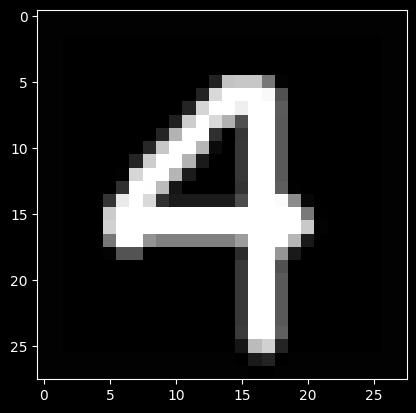

In [7]:
# Imports where the magic happens
from scipy import ndimage
from PIL import Image, ImageFilter
from PIL import ImageOps
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import torchvision
import torch
import os
import numpy as np


# Transform from class code.
normalize_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# Center mass centerization image fixing thing.
# Sources for this:
"""
https://stackoverflow.com/questions/59525640/how-to-center-the-content-object-of-a-binary-image-in-python
https://stackoverflow.com/questions/48440323/how-mnist-really-work
https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.center_of_mass.html
https://www.geeksforgeeks.org/python/how-to-find-width-and-height-of-an-image-using-python/
https://pillow.readthedocs.io/en/stable/reference/ImageOps.html
https://note.nkmk.me/en/python-opencv-pillow-image-size/
"""
def center_mass_fix_image(image):
    # Grabs the image and height of the array which would be 28, 28 since we made a 28x28 pixel image for everything
    height = image.shape[0]
    width = image.shape[1]

    # Grabs the center from them by just dividing by two
    height_center = height / 2
    width_center = width / 2

    # Grabs the center of mass of x and y using scipy
    center_y_mass = ndimage.center_of_mass(image)[0]
    center_x_mass = ndimage.center_of_mass(image)[1]

    # Shifts the image around according to the calculations
    shiftX = int(round(width_center - center_x_mass))
    shiftY = int(round(height_center - center_y_mass))
    shift_image = np.roll(image, shiftX, axis=1)
    shift_image = np.roll(shift_image, shiftY, axis=0)

    # Returns it as an image using PIL from the array.
    return Image.fromarray(shift_image)


"""
Note: Could've done it the Cooper way since I found the same GeeksForGeeks, but I felt like this was going to be a bit better since I did it the same with MNIST
Sources:
https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
https://www.youtube.com/watch?v=er3LoYljvsU&t=103s
"""
class OwnImageDataset(Dataset):
    # This is all from the youtube video, other than the preprocessing in GETITEM

    # Initialization
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.files = os.listdir(root_dir)

    # Length of Files
    def __len__(self):
        return len(self.files)

    # Pre processing, grabs the label which is the first number of every file, converts into Grayscale, converts into numpy array, goes through center of mass function above, creates a padding (heard from Soloman and Nate's group), and resize it back to (1, 28, 28) which is the MNIST 784 size.
    def __getitem__(self, index):
        filename = str(self.files[index])
        path = os.path.join(self.root_dir, filename)
        label = int(filename[0])
        image = Image.open(path).convert("L")
        image_array = np.asarray(image)
        image = center_mass_fix_image(image_array)
        image = ImageOps.expand(image, border=2, fill=0)
        image = image.resize((28, 28))

        # Video just applies the transform.
        if self.transform:
            image = self.transform(image)

        # Return image and the label.
        return image, torch.tensor(label)

# Just from the video, showed the images and the label it had just so I could test if my labels were correct or not.
def showOneImage(data):
    img = data[0]
    label = data[1].item()
    print(img.shape)
    if label == 1:
        print("1")
        plt.imshow(img.permute(1, 2, 0), cmap="gray")
    elif label == 2:
        print("2")
        plt.imshow(img.permute(1, 2, 0), cmap="gray")
    elif label == 3:
        print("3")
        plt.imshow(img.permute(1, 2, 0), cmap="gray")
    elif label == 4:
        print("4")
        plt.imshow(img.permute(1, 2, 0), cmap="gray")
    elif label == 5:
        print("5")
        plt.imshow(img.permute(1, 2, 0), cmap="gray")
    elif label == 6:
        print("6")
        plt.imshow(img.permute(1, 2, 0), cmap="gray")
    elif label == 7:
        print("7")
        plt.imshow(img.permute(1, 2, 0), cmap="gray")
    elif label == 8:
        print("8")
        plt.imshow(img.permute(1, 2, 0), cmap="gray")
    elif label == 9:
        print("9")
        plt.imshow(img.permute(1, 2, 0), cmap="gray")
    else:
        print("error")

# The actual dataset.
ownNumbersDataset = OwnImageDataset(root_dir="./IMAGES", transform=normalize_transform)

# Shows one image and then the label, just to see if my labels and indexes are correct and everything is in place.
test_subject = ownNumbersDataset[17]
showOneImage(test_subject)

In [8]:
from joblib import load
from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import DataLoader as DL

# Load the model.
svm_classifier = load("./MODELS/svm_mnist.joblib")

# Dataloader or custom data set from our own images places in ./IMAGES
testDataset = DL(dataset=ownNumbersDataset, shuffle=False)

# Class code
XTest = []
yTest = []

for img, label in testDataset:
    XTest.append(img.numpy().flatten())
    yTest.append(label)

# Code used above for the original MNIST code / GeeksForGeeks
yPred = svm_classifier.predict(XTest)
print(f"Accuracy: {accuracy_score(yTest, yPred):.2f}")
print(classification_report(yTest, yPred))

Accuracy: 0.97
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      0.75      0.86         4
           2       0.80      1.00      0.89         4
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         4

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40

